In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd
import netCDF4 as nc
from matplotlib.path import Path
import os
# ─────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────
def make_circle_polygon(cx, cy, r, n=100):
    theta = np.linspace(0, 2 * np.pi, n)
    return np.column_stack([cx + r * np.cos(theta),
                             cy + r * np.sin(theta)])

def inpolygon(px, py, poly_x, poly_y):
    poly   = np.column_stack([poly_x, poly_y])
    path   = Path(poly)
    points = np.column_stack([px, py])
    return path.contains_points(points)

def polygon_to_pixels(grid_x, grid_y, polygons):
    """Rasterise a list of polygons onto a regular grid."""
    XX, YY   = np.meshgrid(grid_x, grid_y)
    pts      = np.column_stack([XX.ravel(), YY.ravel()])
    mask_out = np.zeros(pts.shape[0], dtype=bool)
    for poly in polygons:
        path      = Path(poly)
        mask_out |= path.contains_points(pts)
    return mask_out.reshape(XX.shape)

def read_exp(filepath):
    """
    Parse an Elmer/Ice .exp file.
    Handles multi-segment files (segments separated by NaN NaN rows).
    Returns x, y arrays for the first (or only) segment, with NaNs stripped.
    """
    xs, ys = [], []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            # skip header/comment lines
            if not line or line.startswith('#') or line.startswith('!'):
                continue
            parts = line.split()
            if len(parts) != 2:
                continue
            try:
                x_val, y_val = float(parts[0]), float(parts[1])
                xs.append(x_val)
                ys.append(y_val)
            except ValueError:
                continue

    xs = np.array(xs)
    ys = np.array(ys)

    # strip NaN rows (segment separators)
    valid = ~(np.isnan(xs) | np.isnan(ys))
    return xs[valid], ys[valid]
# ─────────────────────────────────────────────
# Paths
# ─────────────────────────────────────────────
data_folder = '../../thermal-model/Amundsen-thermal-output-Yang/thermal-training-data/Thwaites-PIG/'

mask_data     = sio.loadmat(data_folder + 'training/gridded/training_mask.mat')
mask_domain_d = sio.loadmat(data_folder + 'training/gridded/training_mask_domain_continuous.mat')
coord_data    = sio.loadmat(data_folder + 'training/gridded/trainingAll_image_coord.mat')

mask        = mask_data['mask']
mask_domain = mask_domain_d['in_domain_mask'].astype(bool)
training_coord_x = coord_data['training_coord']['xs'][0,0].ravel()
training_coord_y = coord_data['training_coord']['ys'][0,0].ravel()

# domain boundary
domain_x, domain_y = read_exp('../../thermal-model/exp-files/drainage_G-H.exp')

# colormap
lipari_data = sio.loadmat('../../common-data-set/ScientificColourMaps8/lipari/lipari.mat')
lipari_cmap = plt.matplotlib.colors.ListedColormap(lipari_data['lipari'])

# velocity
vel_path = '../../common-data-set/velocity/antarctica_ice_velocity_450m_v2.nc'

# lake table
lake_tbl = pd.read_csv('../../common-data-set/subglacial-lake/AIS_lake_coordinate_dimension.csv')




/tmp/ipykernel_1601189/2850346736.py:52: RuntimeWarning: divide by zero encountered in log10
  h_img = ax.imshow(np.log10(vel_c),


Total lakes in dataset:      675
Lakes inside domain:         25
Lakes with dimension data:   5
Lakes with assumed radius:   20
Mean radius (with data):     8.9 km
Median radius (with data):   7.9 km


/tmp/ipykernel_1601189/2850346736.py:119: RuntimeWarning: divide by zero encountered in log10
  h_img = ax.imshow(np.log10(vel_c),


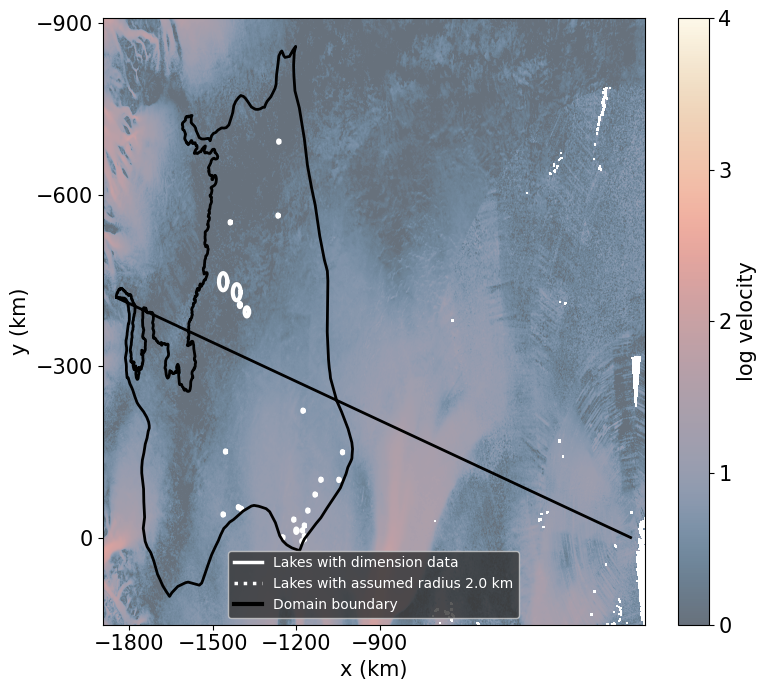

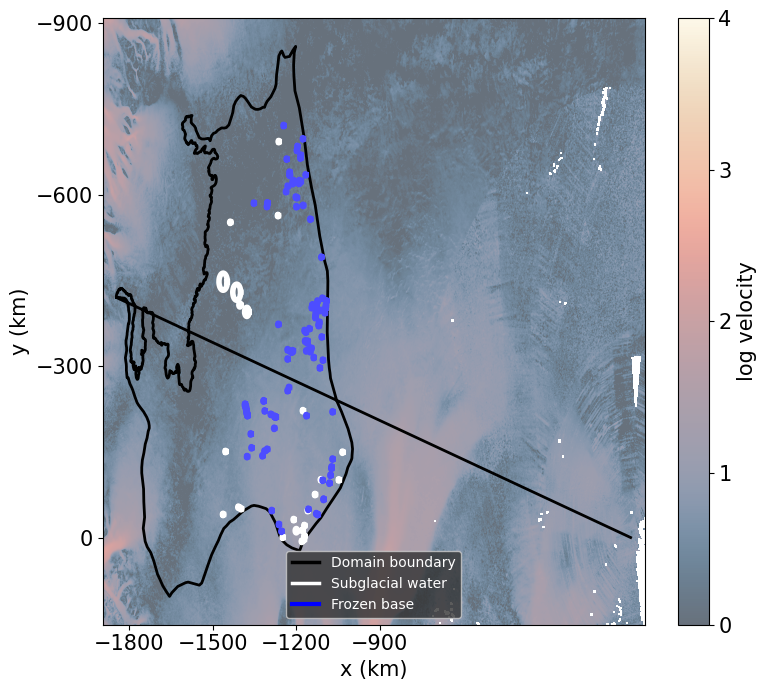

In [19]:

# ─────────────────────────────────────────────
# Load & crop velocity
# ─────────────────────────────────────────────
ds  = nc.Dataset(vel_path)
vx  = np.array(ds['VX'][:], dtype=np.float64)
vy  = np.array(ds['VY'][:], dtype=np.float64)
x   = np.array(ds['x'][:],  dtype=np.float64)
y   = np.array(ds['y'][:],  dtype=np.float64)
ds.close()

vel = np.sqrt(vx**2 + vy**2).T   # transpose to match MATLAB

padding = 50e3
xmin, xmax = domain_x.min() - padding, domain_x.max() + padding
ymin, ymax = domain_y.min() - padding, domain_y.max() + padding

x_idx = (x >= xmin) & (x <= xmax)
y_idx = (y >= ymin) & (y <= ymax)
vel_c = vel[np.ix_(y_idx, x_idx)]
x_c   = x[x_idx]
y_c   = y[y_idx]

# ─────────────────────────────────────────────
# Lake polygons
# ─────────────────────────────────────────────
assumed_area   = (training_coord_x[1] - training_coord_x[0]) * \
                 (training_coord_y[1] - training_coord_y[0])
assumed_radius = np.sqrt(assumed_area / np.pi)
size_prefactor = 1

area   = lake_tbl['length'].values * lake_tbl['width'].values
radius = np.sqrt(area / np.pi)
x_lake = lake_tbl['x'].values
y_lake = lake_tbl['y'].values

in_domain = inpolygon(x_lake, y_lake, domain_x, domain_y)
x_lake    = x_lake[in_domain]
y_lake    = y_lake[in_domain]
radius    = radius[in_domain]

has_radius_data = ~np.isnan(radius)

lakes_polygon = []
for i in range(len(x_lake)):
    r = radius[i] if has_radius_data[i] else size_prefactor * assumed_radius
    lakes_polygon.append(make_circle_polygon(x_lake[i], y_lake[i], r))

# ─────────────────────────────────────────────
# Plot 1: lakes on velocity
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
h_img = ax.imshow(np.log10(vel_c),
                  extent=[x_c[0]/1e3, x_c[-1]/1e3, y_c[0]/1e3, y_c[-1]/1e3],
                  origin='lower', cmap=lipari_cmap, vmin=0, vmax=4,
                  alpha=0.6, aspect='auto')
cb = plt.colorbar(h_img, ax=ax)
cb.set_label('log velocity', fontsize=15)
cb.ax.tick_params(labelsize=15)
cb.set_ticks(range(5))

for i, poly in enumerate(lakes_polygon):
    ls = '-'
    ax.plot(poly[:, 0]/1e3, poly[:, 1]/1e3, color='w', linewidth=3, linestyle=ls)

ax.plot(domain_x/1e3, domain_y/1e3, 'k-', linewidth=2)

h1, = ax.plot([], [], 'w-',  linewidth=2.5, label='Lakes with dimension data')
h2, = ax.plot([], [], 'w:',  linewidth=2.5,
              label=f'Lakes with assumed radius {assumed_radius/1e3:.1f} km')
h3, = ax.plot([], [], 'k-',  linewidth=3,   label='Domain boundary')
leg = ax.legend(handles=[h1, h2, h3], loc='lower center',
                facecolor=[0.2, 0.2, 0.2], labelcolor='white')

ax.set_xlabel('x (km)', fontsize=15)
ax.set_ylabel('y (km)', fontsize=15)
ax.set_xticks(range(-1800, -799, 300))
ax.set_yticks(range(-900, 101, 300))
ax.tick_params(labelsize=15)
plt.tight_layout()

print(f'Total lakes in dataset:      {len(lake_tbl)}')
print(f'Lakes inside domain:         {len(x_lake)}')
print(f'Lakes with dimension data:   {has_radius_data.sum()}')
print(f'Lakes with assumed radius:   {(~has_radius_data).sum()}')
if has_radius_data.sum() > 0:
    print(f'Mean radius (with data):     {np.nanmean(radius[has_radius_data])/1e3:.1f} km')
    print(f'Median radius (with data):   {np.nanmedian(radius[has_radius_data])/1e3:.1f} km')

# ─────────────────────────────────────────────
# Water mask
# ─────────────────────────────────────────────
water_mask_val = polygon_to_pixels(training_coord_x, training_coord_y, lakes_polygon)
water_mask_val[~mask_domain] = False
water_mask = {'data': water_mask_val, 'x': training_coord_x, 'y': training_coord_y}
os.makedirs(data_folder + 'basal-water-mask', exist_ok=True)
sio.savemat(data_folder + 'basal-water-mask/water_mask.mat', {'water_mask': water_mask})

# ─────────────────────────────────────────────
# Frozen base mask
# ─────────────────────────────────────────────
frozen_data = sio.loadmat('../../thermal-model/data/atten-reflect-Amundsen-sea/low_reflectivity.mat')
frozen_x    = frozen_data['frozen']['x'][0,0].ravel()
frozen_y    = frozen_data['frozen']['y'][0,0].ravel()
frozen_refl = frozen_data['frozen']['reflectivity'][0,0].ravel()

in_domain  = inpolygon(frozen_x, frozen_y, domain_x, domain_y)
frozen_x   = frozen_x[in_domain]
frozen_y   = frozen_y[in_domain]
frozen_refl= frozen_refl[in_domain]

r_frozen       = size_prefactor * assumed_radius
frozen_polygon = [make_circle_polygon(frozen_x[i], frozen_y[i], r_frozen)
                  for i in range(len(frozen_x))]

# ─────────────────────────────────────────────
# Plot 2: lakes + frozen together
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
h_img = ax.imshow(np.log10(vel_c),
                  extent=[x_c[0]/1e3, x_c[-1]/1e3, y_c[0]/1e3, y_c[-1]/1e3],
                  origin='lower', cmap=lipari_cmap, vmin=0, vmax=4,
                  alpha=0.6, aspect='auto')
cb = plt.colorbar(h_img, ax=ax)
cb.set_label('log velocity', fontsize=15)
cb.ax.tick_params(labelsize=15)
cb.set_ticks(range(5))

ax.plot(domain_x/1e3, domain_y/1e3, 'k-', linewidth=2)

for poly in lakes_polygon:
    ax.plot(poly[:, 0]/1e3, poly[:, 1]/1e3, '-', linewidth=4, color='w')
for poly in frozen_polygon:
    ax.plot(poly[:, 0]/1e3, poly[:, 1]/1e3, '-', linewidth=4, color=[0.3, 0.3, 1.0])

h1, = ax.plot([], [], 'k-', linewidth=2.5, label='Domain boundary')
h2, = ax.plot([], [], 'w-', linewidth=2.5, label='Subglacial water')
h3, = ax.plot([], [], 'b-', linewidth=3,   label='Frozen base')
leg = ax.legend(handles=[h1, h2, h3], loc='lower center',
                facecolor=[0.2, 0.2, 0.2], labelcolor='white')

ax.set_xlabel('x (km)', fontsize=15)
ax.set_ylabel('y (km)', fontsize=15)
ax.set_xticks(range(-1800, -799, 300))
ax.set_yticks(range(-900, 101, 300))
ax.tick_params(labelsize=15)
plt.tight_layout()
plt.savefig('../figs/basal-evidence-all.png', dpi=400, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# Frozen mask
# ─────────────────────────────────────────────
frozen_mask_val = polygon_to_pixels(training_coord_x, training_coord_y, frozen_polygon)
frozen_mask_val[~mask_domain] = False
frozen_mask = {'data': frozen_mask_val, 'x': frozen_x, 'y': frozen_y}
# os.makedirs(data_folder + 'basal-frozen-mask', exist_ok=True)
# sio.savemat(data_folder + 'basal-frozen-mask/frozen_mask.mat', {'frozen_mask': frozen_mask})

# ─────────────────────────────────────────────
# Resolve conflicts
# ─────────────────────────────────────────────
conflicts = np.where(frozen_mask['data'] & water_mask['data'])
if len(conflicts[0]) > 0:
    water_mask['data'][conflicts]  = False
    frozen_mask['data'][conflicts] = False
    print(f'{len(conflicts[0])} conflicting pixels found and removed.')
    # sio.savemat(data_folder + 'basal-frozen-mask/frozen_mask.mat', {'frozen_mask': frozen_mask})
    # sio.savemat(data_folder + 'basal-water-mask/water_mask.mat',   {'water_mask':  water_mask})
